In [108]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/obaidhere/amazon-bestsellers-price-vs-user-rating-analysis/bestsellers with categories.csv


# What Makes a Bestseller? Analyzing Amazon Book Prices vs User Ratings


## 1. Project Overview
This project explores the relationship between book prices and user ratings among Amazon bestsellers.  
We aim to answer:
- Do higher-priced books have better ratings?
- Are certain genres rated more favorably?
- What factors influence bestseller success?

# 2. Import Libraries

In [109]:
# Step 1: Import necessary libraries
import pandas as pd                 # For data handling
import numpy as np                  # For numerical operations
import matplotlib.pyplot as plt     # For basic plotting
import seaborn as sns               # For advanced visualization
import plotly.express as px         # For interactive plots (optional)

# Make plots more readable
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
plt.rcParams['figure.figsize'] = (12,6)

# 3. Load Dataset

In [110]:
df = pd.read_csv("/kaggle/input/datasets/obaidhere/amazon-bestsellers-price-vs-user-rating-analysis/bestsellers with categories.csv")

# 4. Data Cleaning

In [111]:
# Check missing values
df.isnull().sum()

Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64

In [112]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [113]:
# Remove duplicates if any
df = df.drop_duplicates()

# 5. Data Overview

In [114]:
# Show first 5 rows
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [115]:
# Show last 5 rows
df.tail()

,Name,Author,User Rating,Reviews,Price,Year,Genre
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction
549,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2019,Non Fiction


In [116]:
# Show 5 random rows
df.sample(5)

,Name,Author,User Rating,Reviews,Price,Year,Genre
160,Have a Little Faith: A True Story,Mitch Albom,4.8,1930,4,2009,Non Fiction
381,The Getaway,Jeff Kinney,4.8,5836,0,2017,Fiction
405,The Help,Kathryn Stockett,4.8,13871,7,2011,Fiction
276,Publication Manual of the American Psychologic...,American Psychological Association,4.5,8580,46,2014,Non Fiction
155,Harry Potter and the Goblet of Fire: The Illus...,J. K. Rowling,4.9,7758,18,2019,Fiction


In [117]:
# Overview: rows, columns, data types, memory usage
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    object 
 1   Author       550 non-null    object 
 2   User Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        550 non-null    int64  
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 30.2+ KB


In [118]:
# Check column names
df.columns

Index(['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre'], dtype='object')

In [119]:
# Check dataset shape (rows, columns)
df.shape

(550, 7)

In [120]:
# Default stats: count, mean, std, min, 25%, 50%, 75%, max
df.describe()   

,User Rating,Reviews,Price,Year
count,550.000000,550.000000,550.000000,550.000000
mean,4.618364,11953.281818,13.100000,2014.000000
std,0.226980,11731.132017,10.842262,3.165156
min,3.300000,37.000000,0.000000,2009.000000
25%,4.500000,4058.000000,7.000000,2011.000000
50%,4.700000,8580.000000,11.000000,2014.000000
75%,4.800000,17253.250000,16.000000,2017.000000
max,4.900000,87841.000000,105.000000,2019.000000


In [121]:
# Include categorical columns as well
df.describe(include='all')  

,Name,Author,User Rating,Reviews,Price,Year,Genre
count,550,550,550.000000,550.000000,550.000000,550.000000,550
unique,351,248,NaN,NaN,NaN,NaN,2
top,Publication Manual of the American Psychologic...,Jeff Kinney,NaN,NaN,NaN,NaN,Non Fiction
freq,10,12,NaN,NaN,NaN,NaN,310
mean,NaN,NaN,4.618364,11953.281818,13.100000,2014.000000,NaN
std,NaN,NaN,0.226980,11731.132017,10.842262,3.165156,NaN
min,NaN,NaN,3.300000,37.000000,0.000000,2009.000000,NaN
25%,NaN,NaN,4.500000,4058.000000,7.000000,2011.000000,NaN
50%,NaN,NaN,4.700000,8580.000000,11.000000,2014.000000,NaN
75%,NaN,NaN,4.800000,17253.250000,16.000000,2017.000000,NaN


In [122]:
# Unique genres
df['Genre'].unique()

array(['Non Fiction', 'Fiction'], dtype=object)

In [123]:
# Number of unique authors
df['Author'].nunique()

248

In [124]:
# Count of books per genre
df['Genre'].value_counts()

Genre
Non Fiction    310
Fiction        240
Name: count, dtype: int64

In [125]:
# Count of bestseller appearances per author
df['Author'].value_counts().head(10)

Author
Jeff Kinney                           12
Suzanne Collins                       11
Gary Chapman                          11
Rick Riordan                          11
American Psychological Association    10
Dr. Seuss                              9
Gallup                                 9
Rob Elliott                            8
Bill O'Reilly                          7
Eric Carle                             7
Name: count, dtype: int64

In [126]:
# Check data dytpes
df.dtypes

Name            object
Author          object
User Rating    float64
Reviews          int64
Price            int64
Year             int64
Genre           object
dtype: object

In [127]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['User Rating'] = pd.to_numeric(df['User Rating'], errors='coerce')
df['Year'] = df['Year'].astype(int)
df.dropna(subset=['Price','User Rating'], inplace=True)

In [128]:
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


# 6. Exploratory Data Analysis (EDA)

### 6.1 Distribution of Book Prices

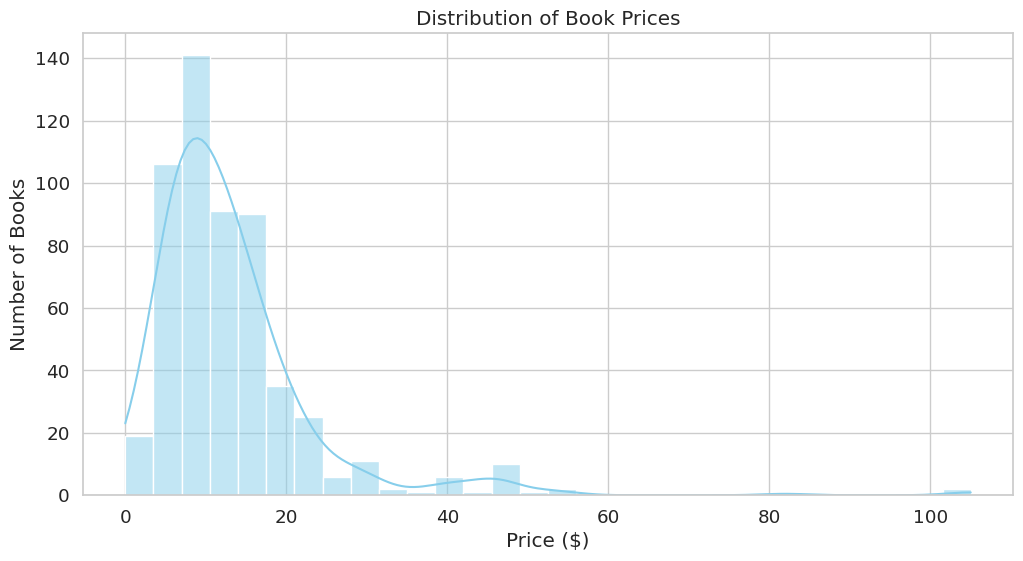

In [129]:
sns.histplot(df['Price'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Book Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Books")
plt.show()

### 6.2 Distribution of User Ratings

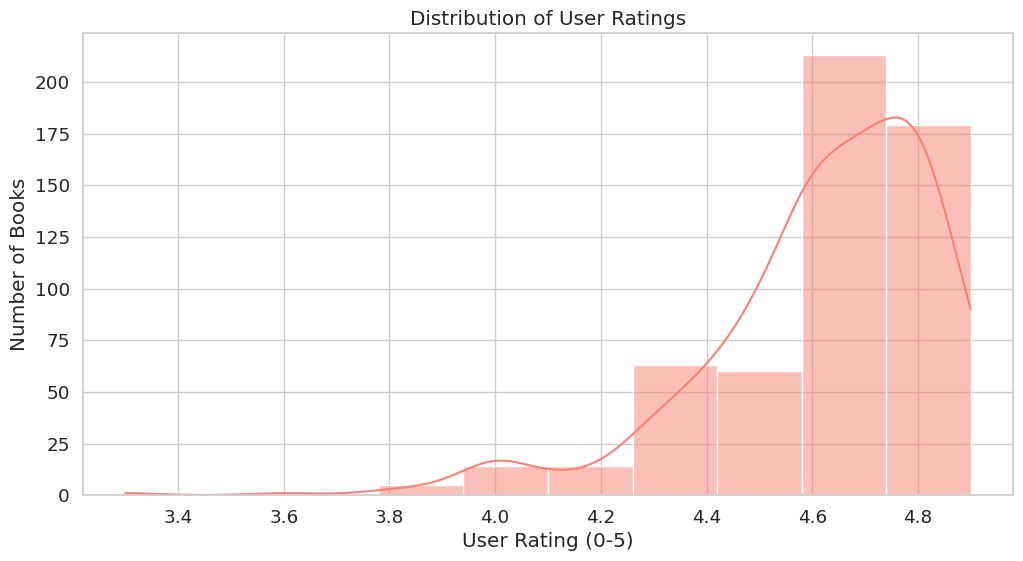

In [130]:
sns.histplot(df['User Rating'], bins=10, kde=True, color='salmon')
plt.title("Distribution of User Ratings")
plt.xlabel("User Rating (0-5)")
plt.ylabel("Number of Books")
plt.show()

### 6.3 Price vs User Rating

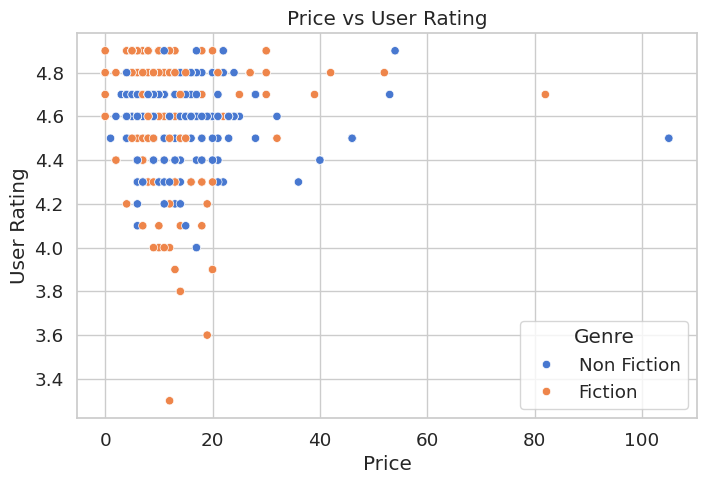

In [131]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Price', y='User Rating', hue='Genre')
plt.title("Price vs User Rating")
plt.xlabel("Price")
plt.ylabel("User Rating")
plt.show()

### 6.4 Genre Comparison

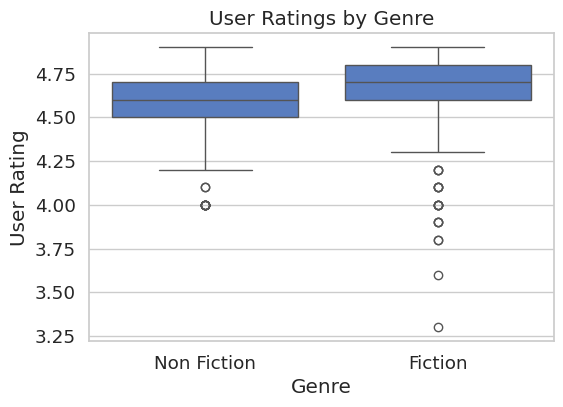

In [132]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Genre', y='User Rating')
plt.title("User Ratings by Genre")
plt.show()

# 7. Correlation Analysis

In [133]:
correlation = df['Price'].corr(df['User Rating'])
print("Correlation:", correlation)

Correlation: -0.13308628728087976


#  8. Top 10 Most Expensive Books

In [134]:
top_expensive = df.sort_values(by='Price', ascending=False).head(10)
top_expensive

,Name,Author,User Rating,Reviews,Price,Year,Genre
69,Diagnostic and Statistical Manual of Mental Di...,American Psychiatric Association,4.5,6679,105,2013,Non Fiction
70,Diagnostic and Statistical Manual of Mental Di...,American Psychiatric Association,4.5,6679,105,2014,Non Fiction
473,The Twilight Saga Collection,Stephenie Meyer,4.7,3801,82,2009,Fiction
151,Hamilton: The Revolution,Lin-Manuel Miranda,4.9,5867,54,2016,Non Fiction
346,The Book of Basketball: The NBA According to T...,Bill Simmons,4.7,858,53,2009,Non Fiction
159,Harry Potter Paperback Box Set (Books 1-7),J. K. Rowling,4.8,13471,52,2016,Fiction
280,Publication Manual of the American Psychologic...,American Psychological Association,4.5,8580,46,2018,Non Fiction
279,Publication Manual of the American Psychologic...,American Psychological Association,4.5,8580,46,2017,Non Fiction
278,Publication Manual of the American Psychologic...,American Psychological Association,4.5,8580,46,2016,Non Fiction
277,Publication Manual of the American Psychologic...,American Psychological Association,4.5,8580,46,2015,Non Fiction


# 9. Top Rated Books

In [135]:
top_rated = df.sort_values(by='User Rating', ascending=False).head(10)
top_rated

,Name,Author,User Rating,Reviews,Price,Year,Genre
521,Unfreedom of the Press,Mark R. Levin,4.9,5956,11,2019,Non Fiction
420,The Legend of Zelda: Hyrule Historia,Patrick Thorpe,4.9,5396,20,2013,Fiction
248,"Oh, the Places You'll Go!",Dr. Seuss,4.9,21834,8,2015,Fiction
247,"Oh, the Places You'll Go!",Dr. Seuss,4.9,21834,8,2014,Fiction
246,"Oh, the Places You'll Go!",Dr. Seuss,4.9,21834,8,2013,Fiction
431,The Magnolia Story,Chip Gaines,4.9,7861,5,2016,Non Fiction
252,"Oh, the Places You'll Go!",Dr. Seuss,4.9,21834,8,2019,Fiction
251,"Oh, the Places You'll Go!",Dr. Seuss,4.9,21834,8,2018,Fiction
250,"Oh, the Places You'll Go!",Dr. Seuss,4.9,21834,8,2017,Fiction
249,"Oh, the Places You'll Go!",Dr. Seuss,4.9,21834,8,2016,Fiction
